In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parent
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [ ]:
model_df = pd.read_csv(
    DATA_RAW/"default_model_df.csv"
)

print(model_df.shape)
model_df.head()

(2255, 65)


,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,domestic_release_date,...,actor_2,actor_3,actor_4_y,actor_5_y,actor_6_y,director_name_y,writer_name_y,actor_1_name_y,actor_2_name_y,actor_3_name_y
0,0,tt0120667,Fantastic Four,2005.0,https://www.the-numbers.com/movie/Fantastic-Fo...,True,NaN,56061504.0,3602.0,2005-07-08,...,nm0004821,nm0262635,nm0004695,nm0573037,nm0512934,Tim Story,Mark Frost,Ioan Gruffudd,Michael Chiklis,Chris Evans
1,1,tt0121164,Corpse Bride,2005.0,https://www.the-numbers.com/movie/Corpse-Bride,True,NaN,19145480.0,3204.0,2005-09-16,...,nm0000307,nm0001833,nm0001808,nm0925768,NaN,Tim Burton,John August,Johnny Depp,Helena Bonham Carter,Emily Watson
2,2,tt0121766,Star Wars: Episode III - Revenge of the Sith,2005.0,https://www.the-numbers.com/movie/Star-Wars-Ep...,True,NaN,108435841.0,3661.0,2005-05-19,...,nm0000204,nm0000191,nm0000168,nm0001519,nm0001751,George Lucas,George Lucas,Hayden Christensen,Natalie Portman,Ewan McGregor
3,3,tt0167190,Hellboy,2004.0,https://www.the-numbers.com/movie/Hellboy,True,NaN,23172440.0,3028.0,2004-04-02,...,nm0427964,nm0004757,nm0000457,nm1140344,nm0734558,Guillermo del Toro,Guillermo del Toro,Ron Perlman,Doug Jones,Selma Blair
4,4,tt0200465,The Bank Job,2008.0,https://www.the-numbers.com/movie/Bank-Job-The,True,NaN,5935256.0,1603.0,2008-03-07,...,nm0004787,nm1304386,nm0990547,nm0269077,nm0202810,Roger Donaldson,Dick Clement,Jason Statham,Saffron Burrows,Stephen Campbell Moore


In [4]:
target = "log_opening_weekend_gross"

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
]

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
] + people_features

In [5]:
for col in people_features:

    counts = model_df[col].value_counts(dropna=False)

    other_count = (model_df[col] == "OTHER").sum()

    print("\n" + "=" * 50)
    print(col)

    print(f"Unique values: {model_df[col].nunique(dropna=False)}")
    print(f"OTHER count: {other_count}")
    print(f"OTHER %: {other_count / len(model_df):.3f}")

    print("\nTop values:")
    print(counts.head(10))


director_id
Unique values: 1108
OTHER count: 0
OTHER %: 0.000

Top values:
director_id
nm0000631    15
nm0000142    15
nm0000229    13
nm0000095    12
nm1347153    11
nm0000318    10
nm0298807     9
nm0000165     9
nm0634240     9
nm0506613     9
Name: count, dtype: int64

writer_id
Unique values: 1435
OTHER count: 0
OTHER %: 0.000

Top values:
writer_id
NaN          13
nm0000095    12
nm1347153    12
nm1191481     9
nm0921013     9
nm0472567     8
nm0604555     8
nm0027271     7
nm0027572     7
nm0934483     7
Name: count, dtype: int64

actor_1
Unique values: 939
OTHER count: 0
OTHER %: 0.000

Top values:
actor_1
nm0425005    22
nm0001191    20
nm0002071    19
nm0000136    18
nm0000243    18
nm0000242    18
nm0000158    17
nm0136797    17
nm0000115    16
nm0000129    16
Name: count, dtype: int64

actor_2
Unique values: 1286
OTHER count: 0
OTHER %: 0.000

Top values:
actor_2
NaN          24
nm0000168    13
nm0000949    10
nm0004937    10
nm0005562     9
nm0933940     9
nm1046097     9

In [6]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 18)
(2255,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
y_test_dollars = np.expm1(y_test)

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [11]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.5531830480981474,
 'mae_log': 0.8761171075398863,
 'mae_dollars': 17085995.383381285}

In [12]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.604596846945843,
 'mae_log': 0.7834158158241772,
 'mae_dollars': 13343546.596229292}

In [13]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.553183,0.876117,1.708600e+07
1,XGBoost Baseline,0.604597,0.783416,1.334355e+07


In [14]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [15]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [16]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

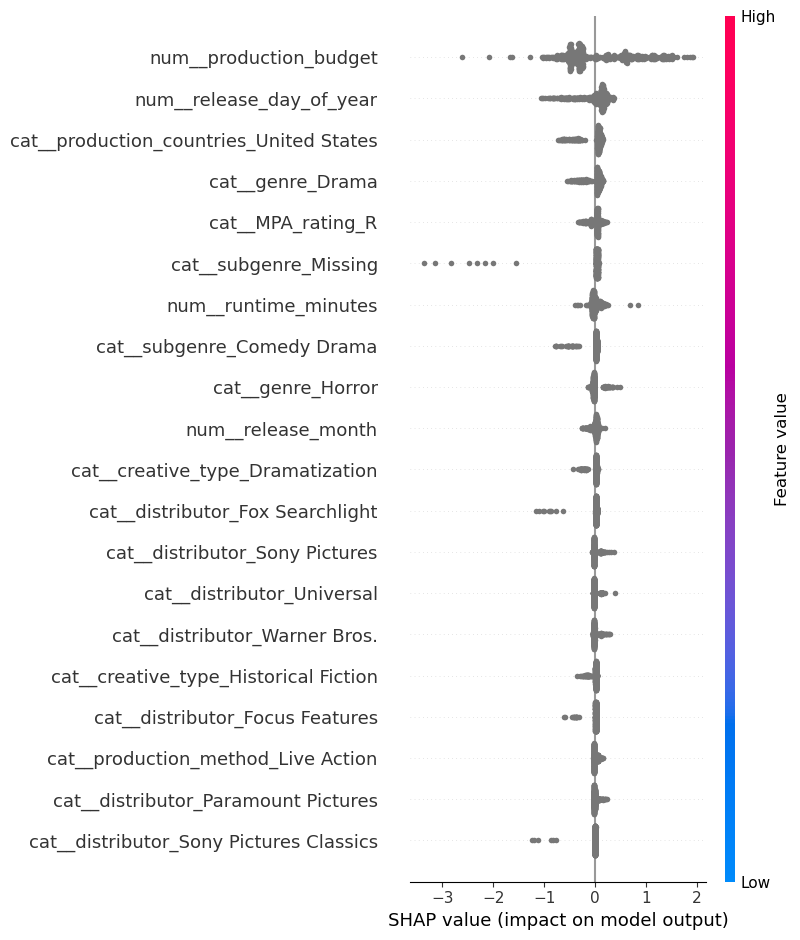

In [17]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

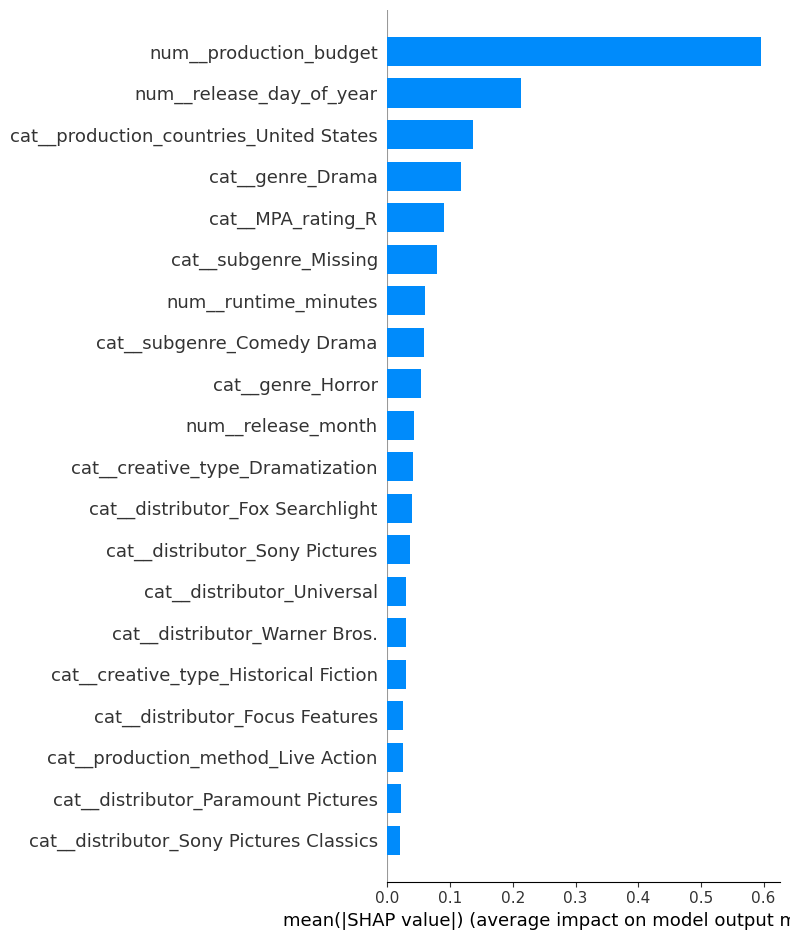

In [18]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

## Notes on Feature Leakage, Forecasting Stages, and Modeling Tiers

During baseline modeling, opening theater count dramatically increased model performance:

- XGBoost without `opening_theaters` and `release_type`
  - R² ≈ 0.59

- XGBoost with `opening_theaters` and `release_type`
  - R² ≈ 0.90

This suggests that theater count and release strategy encode substantial downstream market information.

Although `opening_theaters` exists before opening weekend numerically, it is not an intrinsic movie attribute. Theater count is likely influenced by many hidden industry forecasting signals, including:

- trailer engagement
- social media hype
- advance ticket sales
- franchise familiarity
- tracking surveys
- marketing expectations
- exhibitor confidence
- critic expectations

Similarly, `release_type` (Wide, Limited, Expands Wide) likely reflects studio confidence and rollout strategy decisions informed by expected demand.

This creates an important distinction between:
- intrinsic movie characteristics
- market/distribution confidence signals

Rather than treating all features equally, the project may be better framed as a series of forecasting stages.

---

## Proposed Modeling Tiers

### Tier 1 — Intrinsic Metadata Model
Attempts to predict opening weekend using mostly intrinsic or structural movie characteristics.

Potential features:
- genre
- subgenre
- source material
- creative type
- production method
- runtime
- MPA rating
- production budget
- cast/director features
- engineered semantic features

Excludes:
- opening theater count
- release type

Goal:
Estimate how predictable audience demand is from movie characteristics alone.

---

### Tier 2 — Pre-Release Market Information Model
Adds real-world market-facing information that is publicly known before release.

Additional features:
- distributor
- release date/month/seasonality
- competition density
- Google Trends
- social media metrics
- trailer engagement

Goal:
Estimate how much additional predictive power comes from observable market positioning and audience awareness.

---

### Tier 3 — Distribution Strategy Model
Adds studio deployment and rollout decisions.

Additional features:
- opening theater count
- release type

Goal:
Estimate opening weekend after incorporating the industry's own distribution confidence signals.

This tier likely reflects not only movie quality or audience demand, but also the forecasting ability of studios and exhibitors themselves.

In [19]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,distributor,MPA_rating,genre,subgenre,source,production_method,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1926,400000000.0,181.0,4,116,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Animation/Live Action,...,nm0751577,nm1321655,nm0000375,nm0262635,nm0749263,19.693568,18.746218,3.571150e+08,138477408.0,2.186376e+08
900,200000000.0,148.0,12,351,Sony Pictures,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Animation/Live Action,...,nm1218281,nm0571344,nm4043618,nm3918035,nm1212722,19.376725,18.440851,2.601386e+08,102037528.0,1.581010e+08
174,215000000.0,124.0,6,163,Universal,PG-13,Action,Action Adventure,Based on Fiction Book/Short Story,Live Action,...,nm1119880,nm0415425,nm0695435,nm0397171,nm1339223,19.156917,18.009605,2.088063e+08,66293700.0,1.425126e+08
1469,200000000.0,120.0,2,47,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Live Action,...,nm3363032,nm3363032,nm1569276,nm0430107,nm2143282,19.123798,18.071779,2.020040e+08,70546264.0,1.314577e+08
2244,200000000.0,126.0,5,126,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Animation/Live Action,...,nm0000600,nm5642271,nm1212722,nm0647634,nm0252230,19.048868,17.896519,1.874210e+08,59205128.0,1.282159e+08
1271,145000000.0,114.0,7,202,Warner Bros.,PG-13,Comedy,Satirical Comedy,Based on Toy,Live Action,...,nm1950086,nm1950086,nm3053338,nm0331516,nm4793987,18.903243,17.512991,1.620220e+08,40345520.0,1.216765e+08
1207,58000000.0,107.0,2,43,20th Century Fox,R,Action,Action Comedy,Spin-Off,Animation/Live Action,...,nm1783265,nm1014201,nm0005351,nm1072555,nm2554352,18.701600,16.939690,1.324346e+08,22741216.0,1.096934e+08
997,160000000.0,123.0,3,76,Walt Disney,PG,Musical,Family Musical,Based on Folk Tale/Legend/Fairytale,Animation/Live Action,...,NaN,NaN,nm5177626,nm11380870,nm3592451,18.978870,18.038387,1.747506e+08,68229480.0,1.065211e+08
1402,136200000.0,115.0,11,321,Lionsgate,PG-13,Drama,Romantic Drama,Based on Fiction Book/Short Story,Live Action,...,nm0174374,nm2769412,nm0829576,nm1500155,nm1210124,18.764750,17.410400,1.410676e+08,36411688.0,1.046559e+08
1151,150000000.0,100.0,11,332,Walt Disney,PG,Musical,Musical-Adventure,Original Screenplay,Digital Animation,...,nm3989471,nm1158544,nm7635388,nm0425005,nm12533314,18.755633,17.378408,1.397874e+08,35265244.0,1.045221e+08


In [20]:
results_df.to_csv(
    DATA_PROCESSED/"full_baseline_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"full_baseline_xgb_test_errors.csv",
    index=False
)